# Detecteur de spam SMS - Projet AT&T

Objectif : a partir du seul contenu d'un SMS, predire s'il s'agit d'un spam ou d'un message normal (ham).

Deux modeles sont testes :
1. Un modele simple, entraine de zero (embedding + couches denses).
2. Un modele de transfer learning, base sur DistilBERT pre-entraine.

Jeu de donnees : SMS Spam Collection (5572 SMS en anglais, etiquetes ham/spam).

## 1. Imports

In [1]:
#!pip install spacy
#!python -m spacy download en_core_web_md
#!pip install tensorflow transformers scikit-learn matplotlib
#!pip install tf-keras
#!pip install "tensorflow==2.15.0" "transformers==4.40.0" tf-keras
#pip install "tensorflow==2.15.0" "numpy<2.0" tf-keras "transformers==4.40.0

In [2]:
import numpy as np
import pandas as pd
import re
import spacy
from spacy.lang.en.stop_words import STOP_WORDS

import tensorflow as tf
from transformers import TFAutoModel, AutoTokenizer

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
import matplotlib.pyplot as plt

RANDOM_STATE = 2
np.random.seed(RANDOM_STATE)

c:\Users\surel\anaconda3\envs\att_spam\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Chargement des donnees

In [3]:
data = pd.read_csv('spam.csv', encoding='ISO-8859-1')
data = data[['v1', 'v2']].rename(columns={'v1': 'label', 'v2': 'message'})
data['label'].value_counts()

label
ham     4825
spam     747
Name: count, dtype: int64

Le jeu de donnees est desequilibre : environ 13% de spams seulement. On en tiendra compte au moment du split.

## 3. Pretraitement du texte

Trois etapes : nettoyage (minuscules + ponctuation), lemmatisation (spaCy, pour reduire chaque mot a sa forme de base et retirer les mots vides), puis tokenisation + padding pour obtenir des sequences de meme longueur.

In [4]:
def clean_text(text):
    return re.sub(r'[^\w\s]', '', text).lower()

nlp = spacy.load('en_core_web_md')

def lemmatize(text):
    doc = nlp(text)
    return " ".join(token.lemma_ for token in doc if token.lemma_ not in STOP_WORDS)

data['message_clean'] = data['message'].apply(clean_text).apply(lemmatize)
data[['message', 'message_clean']].head(3)

,message,message_clean
0,"Go until jurong point, crazy.. Available only ...",jurong point crazy available bugis n great wor...
1,Ok lar... Joking wif u oni...,ok lar joke wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry 2 wkly comp win fa cup final tkts 2...


In [5]:
VOCAB_SIZE = 2000

tokenizer = tf.keras.preprocessing.text.Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(data['message_clean'])
data['tokens'] = tokenizer.texts_to_sequences(data['message_clean'])

MAX_LEN = max(len(seq) for seq in data['tokens'])
print(f"Longueur max d'un message (en tokens) : {MAX_LEN}")

Longueur max d'un message (en tokens) : 73


## 4. Separation des donnees

On met de cote un ensemble de validation qui garde la vraie repartition des classes (13% de spam), pour juger les modeles de facon honnete. Sur le reste, on reduit le nombre de hams (undersampling) pour rendre l'entrainement moins desequilibre, puis on separe en train/test.

In [6]:
def undersample(df, ratio=4):
    spam = df[df.label == 'spam']
    ham = df[df.label == 'ham'].sample(ratio * len(spam), random_state=RANDOM_STATE)
    return pd.concat([ham, spam]).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

data_train_full, data_val = train_test_split(
    data, test_size=0.15, stratify=data['label'], random_state=RANDOM_STATE
)
data_train_balanced = undersample(data_train_full, ratio=4)

encoder = LabelEncoder().fit(data_train_balanced['label'])
y_train_val = encoder.transform(data_train_balanced['label'])
y_val = encoder.transform(data_val['label'])

def pad(sequences):
    return tf.keras.preprocessing.sequence.pad_sequences(sequences, padding='post', maxlen=MAX_LEN)

X_train, X_test, y_train, y_test = train_test_split(
    pad(data_train_balanced['tokens']), y_train_val, test_size=0.15,
    stratify=y_train_val, random_state=RANDOM_STATE
)
X_val = pad(data_val['tokens'])

BATCH_SIZE = 64
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).shuffle(len(X_train)).batch(BATCH_SIZE)
test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(BATCH_SIZE)

print(f"Train : {len(X_train)}  Test : {len(X_test)}  Validation : {len(X_val)}")

Train : 2698  Test : 477  Validation : 836


## 5. Fonction d'evaluation

Utilisee pour les deux modeles : predit sur l'ensemble de validation et affiche accuracy, precision, recall et la matrice de confusion.

In [7]:
def evaluate_model(model, X, y, title=""):
    y_pred = np.where(model.predict(X, verbose=0) > 0.5, 1, 0)
    acc, prec, rec = accuracy_score(y, y_pred), precision_score(y, y_pred), recall_score(y, y_pred)
    cm = confusion_matrix(y, y_pred)

    print(f"{title}\nAccuracy : {acc:.4f}   Precision : {prec:.4f}   Recall : {rec:.4f}")

    fig, ax = plt.subplots(figsize=(3.5, 3))
    ax.imshow(cm, cmap="Blues")
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(["ham", "spam"]); ax.set_yticklabels(["ham", "spam"])
    ax.set_xlabel("Prediction"); ax.set_ylabel("Reel")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                     color="white" if cm[i, j] > cm.max() / 2 else "black", fontweight="bold")
    plt.tight_layout(); plt.show()

## 6. Modele 1 - Baseline

Le modele le plus simple possible : une couche d'embedding, un pooling qui resume le SMS en un seul vecteur, puis deux couches denses pour la classification. Pas de couche recurrente, pas de transfer learning.

Epoch 1/20
43/43 [==============================] - 1s 9ms/step - loss: 0.5811 - accuracy: 0.7958 - precision: 0.2963 - recall: 0.0148 - val_loss: 0.4786 - val_accuracy: 0.8008 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/20
43/43 [==============================] - 0s 5ms/step - loss: 0.4593 - accuracy: 0.7999 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_loss: 0.4400 - val_accuracy: 0.8008 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/20
43/43 [==============================] - 0s 5ms/step - loss: 0.4245 - accuracy: 0.7999 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_loss: 0.3933 - val_accuracy: 0.8008 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 4/20
43/43 [==============================] - 0s 5ms/step - loss: 0.3482 - accuracy: 0.8091 - precision: 0.9310 - recall: 0.0500 - val_loss: 0.2957 - val_accuracy: 0.8260 - val_precision: 0.8750 - val_recall: 0.1474
Epoch 5/20
43/43 [==============================] - 0s 5ms/step - loss: 

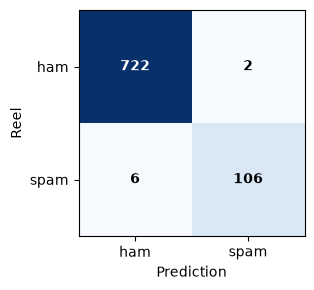

In [11]:
model_1 = tf.keras.Sequential([
    tf.keras.layers.Embedding(VOCAB_SIZE + 1, 128, input_shape=(X_train.shape[1],)),
    tf.keras.layers.GlobalAveragePooling1D(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(1, activation='sigmoid'),
])
model_1.compile(optimizer='adam', loss='binary_crossentropy',
                 metrics=['accuracy', tf.keras.metrics.Precision(name='precision'), tf.keras.metrics.Recall(name='recall')])

model_1.fit(train_ds, epochs=20, validation_data=test_ds, verbose=1)
evaluate_model(model_1, X_val, y_val, title="Modele 1 - Baseline")

Deja de tres bons resultats avec ce modele simple : 98,7% d'accuracy. Le point faible est le recall (93,8%) : quelques spams ne sont pas detectes.

## 7. Modele 2 - Transfer learning avec DistilBERT

Plutot que d'entrainer un modele de zero, on reutilise un DistilBERT deja pre-entraine specifiquement pour la detection de spam SMS ([Manirathinam21/DistilBert_SMSSpam_classifier](https://huggingface.co/Manirathinam21/DistilBert_SMSSpam_classifier), disponible sur Hugging Face). On gele ses poids et on entraine seulement une petite tete de classification par-dessus.

Cela demande un tokenizer different, propre a ce modele.

In [12]:
bert_tokenizer = AutoTokenizer.from_pretrained('Manirathinam21/DistilBert_SMSSpam_classifier')
bert_model = TFAutoModel.from_pretrained('Manirathinam21/DistilBert_SMSSpam_classifier')

def tokenize_for_bert(texts, max_length=MAX_LEN + 20):
    ids = np.zeros((len(texts), max_length), dtype='int32')
    mask = np.zeros((len(texts), max_length), dtype='int32')
    for i, text in enumerate(texts):
        encoded = bert_tokenizer.encode_plus(
            text, max_length=max_length, truncation=True, padding='max_length',
            add_special_tokens=True, return_tensors='tf',
        )
        ids[i], mask[i] = encoded['input_ids'], encoded['attention_mask']
    return ids, mask

X_train_txt, X_test_txt, y_train2, y_test2 = train_test_split(
    data_train_balanced['message'], y_train_val, test_size=0.2, stratify=y_train_val, random_state=RANDOM_STATE
)

ids_train, mask_train = tokenize_for_bert(X_train_txt)
ids_test, mask_test = tokenize_for_bert(X_test_txt)
ids_val, mask_val = tokenize_for_bert(data_val['message'])

c:\Users\surel\anaconda3\envs\att_spam\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some layers from the model checkpoint at Manirathinam21/DistilBert_SMSSpam_classifier were not used when initializing TFDistilBertModel: ['classifier', 'dropout_19', 'pre_classifier']
- This IS expected if you are initializing TFDistilBertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
All the layers of TFDistilBertModel were initia

In [15]:
class PrintCallback(tf.keras.callbacks.Callback):
    def on_train_batch_end(self, batch, logs=None):
        print(f"batch {batch} - loss: {logs['loss']:.4f}", flush=True)

In [ ]:
input_ids = tf.keras.layers.Input(shape=(MAX_LEN + 20,), dtype='int32', name='input_ids')
attention_mask = tf.keras.layers.Input(shape=(MAX_LEN + 20,), dtype='int32', name='attention_mask')

embeddings = bert_model(input_ids, attention_mask=attention_mask)[0]
x = tf.keras.layers.GlobalMaxPool1D()(embeddings)
x = tf.keras.layers.Dense(32, activation='relu')(x)
x = tf.keras.layers.Dropout(0.1)(x)
output = tf.keras.layers.Dense(1, activation='sigmoid')(x)

model_2 = tf.keras.Model(inputs=[input_ids, attention_mask], outputs=output)
model_2.layers[2].trainable = False  # on gele le modele DistilBERT pre-entraine

model_2.compile(optimizer='adam', loss='binary_crossentropy',
                 metrics=['accuracy', tf.keras.metrics.Precision(name='precision'), tf.keras.metrics.Recall(name='recall')])

train_ds_bert = tf.data.Dataset.from_tensor_slices(
    ({'input_ids': ids_train, 'attention_mask': mask_train}, y_train2)
).shuffle(len(ids_train)).batch(BATCH_SIZE)
test_ds_bert = tf.data.Dataset.from_tensor_slices(
    ({'input_ids': ids_test, 'attention_mask': mask_test}, y_test2)
).batch(BATCH_SIZE)

model_2.fit(train_ds_bert, epochs=10, validation_data=test_ds_bert,
            verbose=0, callbacks=[PrintCallback()])

batch 0 - loss: 0.6973
batch 1 - loss: 0.5168
batch 2 - loss: 0.4190
batch 3 - loss: 0.3433
batch 4 - loss: 0.2931
batch 5 - loss: 0.2559
batch 6 - loss: 0.2280
batch 7 - loss: 0.2048
batch 8 - loss: 0.1837
batch 9 - loss: 0.1672
batch 10 - loss: 0.1533
batch 11 - loss: 0.1409
batch 12 - loss: 0.1383
batch 13 - loss: 0.1288
batch 14 - loss: 0.1214
batch 15 - loss: 0.1140
batch 16 - loss: 0.1120
batch 17 - loss: 0.1059
batch 18 - loss: 0.1005
batch 19 - loss: 0.0956
batch 20 - loss: 0.0911
batch 21 - loss: 0.0870
batch 22 - loss: 0.0833
batch 23 - loss: 0.0799
batch 24 - loss: 0.0767
batch 25 - loss: 0.0738
batch 26 - loss: 0.0712
batch 27 - loss: 0.0687
batch 28 - loss: 0.0663
batch 29 - loss: 0.0682
batch 30 - loss: 0.0662
batch 31 - loss: 0.0642
batch 32 - loss: 0.0622
batch 33 - loss: 0.0604
batch 34 - loss: 0.0587
batch 35 - loss: 0.0571
batch 36 - loss: 0.0556
batch 37 - loss: 0.0563
batch 38 - loss: 0.0549
batch 39 - loss: 0.0540
batch 0 - loss: 0.0008
batch 1 - loss: 0.0014
batc

## 8. Conclusion

| Modele | Accuracy | Precision | Recall |
|---|---|---|---|
| 1. Baseline (embedding + dense) | 0.9868 | 0.9633 | 0.9375 |
| 2. Transfer learning (DistilBERT) | 0.9964 | 1.0000 | 0.9732 |

Le modele simple donne deja de tres bons resultats. Le transfer learning fait mieux sur les trois metriques, en particulier la precision (aucun message legitime bloque a tort dans l'ensemble de validation).

Modele retenu : le modele 2 (DistilBERT), pour ses meilleures performances globales.